# Parcial Final – Análisis de Datos para Redes Sociales  
### Shein vs Temu – Guía de Preguntas de Negocio

Este cuaderno está diseñado para acompañar el **parcial final**.  
No contiene las soluciones, sino una **secuencia de preguntas de negocio** que debes ir respondiendo a partir de tus análisis en Python (celdas de código) y tus conclusiones (texto).

> **Instrucción general:**  
> - Debajo de cada bloque de preguntas encontrarás una celda vacía de código para que hagas el análisis.  
> - Después de tu código, agrega una celda de texto (Markdown) con tus respuestas e interpretaciones de negocio.


In [1]:
!wget https://github.com/javierherrera1996/IntroMachineLearning/raw/refs/heads/main/TercerCorte/shein.csv

--2025-11-26 23:46:32--  https://github.com/javierherrera1996/IntroMachineLearning/raw/refs/heads/main/TercerCorte/shein.csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/IntroMachineLearning/refs/heads/main/TercerCorte/shein.csv [following]
--2025-11-26 23:46:32--  https://raw.githubusercontent.com/javierherrera1996/IntroMachineLearning/refs/heads/main/TercerCorte/shein.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1760315 (1.7M) [text/plain]
Saving to: ‘shein.csv’

shein.csv           100%[===================>]   1.68M  --.-KB/s    in 0.06s   

2025-11-26 23:46:32 (27

In [2]:
!wget https://github.com/javierherrera1996/IntroMachineLearning/raw/refs/heads/main/TercerCorte/temu.csv

--2025-11-26 23:46:40--  https://github.com/javierherrera1996/IntroMachineLearning/raw/refs/heads/main/TercerCorte/temu.csv
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/IntroMachineLearning/refs/heads/main/TercerCorte/temu.csv [following]
--2025-11-26 23:46:40--  https://raw.githubusercontent.com/javierherrera1996/IntroMachineLearning/refs/heads/main/TercerCorte/temu.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 346171 (338K) [text/plain]
Saving to: ‘temu.csv’

temu.csv            100%[===================>] 338.06K  --.-KB/s    in 0.03s   

2025-11-26 23:46:40 (10.3 MB

## 2. Ingesta y Unificación de Datos  
**Objetivo de negocio:** asegurar que estamos comparando peras con peras (Shein vs Temu en una misma tabla limpia).

### 2.1. Preguntas de negocio

1. **Foto grande del dataset**
   - ¿Cuántas publicaciones tenemos de Shein y cuántas de Temu?  
   - ¿Esta diferencia de volumen ya nos dice algo de la estrategia de cada marca?

2. **Comparabilidad**
   - Si Shein tiene mucho más contenido que Temu, ¿por qué NO podemos comparar solo el número de likes o de posts?  
   - ¿Qué riesgos habría para una decisión de inversión si comparamos métricas crudas sin normalizar?

3. **Estructura de la tabla unificada**
   - En el dataframe final unificado (por ejemplo, `df`), ¿qué columnas consideras **clave de negocio** para comparar marcas? (ej: `brand`, `likes`, `comments`, `views`, `published_at`, etc.).  
   - Si una columna no existe en una de las dos fuentes (por ejemplo, `views` solo para algunos posts), ¿cómo afecta eso la interpretación del desempeño?

4. **Representatividad**
   - ¿El periodo de tiempo cubierto en Shein y Temu es el mismo?  
   - Si no lo es, ¿cómo podría sesgar tus conclusiones sobre quién lo está haciendo “mejor”?


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_shein = pd.read_csv('https://github.com/javierherrera1996/IntroMachineLearning/raw/refs/heads/main/TercerCorte/shein.csv')
df_temu = pd.read_csv('https://github.com/javierherrera1996/IntroMachineLearning/raw/refs/heads/main/TercerCorte/temu.csv')
df_shein['brand'] = 'Shein'
df_temu['brand'] = 'Temu'
df = pd.concat([df_shein, df_temu], ignore_index=True)

print(df['brand'].value_counts())



brand
Shein    200
Temu      28
Name: count, dtype: int64


Foto grande: Probablemente verás que Shein tiene muchos más posts que Temu. Esto indica que Shein juega a la saturación y Temu a la irrupción.

Comparabilidad: No podemos comparar likes totales. Si Shein publica 10 veces más, tendrá más likes totales aunque su contenido sea peor. Debemos usar promedios o tasas. Riesgo: Si un inversor solo mira el total, pondría dinero en la marca que "hace más ruido" en lugar de la que "convence mejor".

Representatividad: Si los datos de Shein son de 2020-2023 y Temu solo de 2023, comparar totales es injusto. Sesga la conclusión haciendo parecer a Shein "más grande" de lo que es hoy en día en términos de tendencia actual.

## 3. Limpieza de Métricas  
**Objetivo de negocio:** asegurar que las métricas que usamos representen realidad y no errores de scraping o outliers raros.

### 3.1. Preguntas de negocio

1. **Datos faltantes**
   - ¿Qué porcentaje de posts tiene valores faltantes en métricas clave (ej. `likes`, `comments`, `views`)?  
   - Desde el punto de vista de negocio, ¿qué harías con esos posts: los excluirías, los imputarías o los analizarías aparte? ¿Por qué?

2. **Outliers**
   - Identifica algunos posts con números extremadamente altos de likes o views.  
   - ¿Crees que son orgánicos o podrían ser campañas pagas / virales específicos?  
   - ¿Cómo cambia tu lectura si incluyes vs. excluyes estos outliers?

3. **Calidad de la métrica**
   - Si un post tiene 0 comments pero muchos likes, ¿qué hipótesis de negocio podrías plantear sobre ese tipo de contenido o audiencia?  
   - ¿Qué te preocupa más como inversor: muchos likes con poco comentario, o pocos likes pero una tasa de comentarios alta? Explica.


In [4]:

print(df.isnull().sum())

q99 = df['likesCount'].quantile(0.99)
outliers = df[df['likesCount'] > q99]
print(f"Umbral de viralidad (Top 1%): {q99}")

alt                     105
audioUrl                123
caption                   1
childPosts/0/alt        167
childPosts/0/caption    228
                       ... 
videoDuration           123
videoPlayCount          123
videoUrl                123
videoViewCount          123
brand                     0
Length: 634, dtype: int64
Umbral de viralidad (Top 1%): 27638.01999999998


Datos faltantes: Si faltan views en posts antiguos o tipo "carrusel", y los eliminas, pierdes historia. Mejor analizarlos aparte o imputar con la media del mes.

Outliers: Los posts con millones de likes suelen ser sorteos o virales pagados. Si los incluyes, el promedio se dispara y miente sobre el desempeño "normal".

Decisión: Para evaluar la consistencia diaria, exclúyelos o usa la mediana.

Calidad: Muchos likes con 0 comments = Bots o contenido muy pasivo. Como inversor, prefiero menos likes y más comentarios, porque comentar requiere esfuerzo real.

## 4. Creación de KPIs de Negocio  
**Objetivo:** pasar de métricas vanidosas (likes brutos) a métricas de eficiencia (engagement).

Supongamos que creas un indicador como:

\>
\> `engagement_rate = (likes + comments) / views`  
\> *(ajústalo si tu dataset usa otras métricas)*

### 4.1. Preguntas de negocio

1. **Definición de eficiencia**
   - En tus palabras: ¿qué es “eficiencia” en una estrategia de contenido?  
   - ¿Por qué `engagement_rate` puede ser mejor indicador que los `likes` totales para comparar dos marcas con tamaños y volúmenes distintos?

2. **Comparación entre marcas**
   - Calculando el `engagement_rate` medio y mediano de Shein vs Temu:
     - ¿Cuál de las dos marcas parece **más eficiente** captando atención real por post?  
     - Si fueras un fondo de inversión, ¿este dato te haría mirar con mejores ojos a una de las dos? ¿Por qué?

3. **Distribución del engagement**
   - Mirando la distribución (por ejemplo, un boxplot) del engagement por marca:
     - ¿Shein tiene más posts “mediocres” y unos pocos muy buenos?  
     - ¿Temu tiene menos posts pero más consistentes?  
     - ¿Qué tipo de distribución preferirías si fueras CMO?

4. **Trade-off volumen vs eficiencia**
   - Si Shein publica mucho más, pero su engagement promedio es menor:
     - ¿Crees que están “quemando” a la audiencia con exceso de contenido?  
     - ¿O puede ser una estrategia deliberada de saturación que igual les funciona?


In [6]:
df['engagement_rate'] = (df['likesCount'] + df['commentsCount']) / df['videoViewCount']

print(df.groupby('brand')['engagement_rate'].describe())

       count      mean       std       min       25%       50%       75%  \
brand                                                                      
Shein   79.0  0.371577  0.871439  0.002547  0.024198  0.041624  0.103481   
Temu    26.0  0.020929  0.008436  0.008968  0.016744  0.018851  0.024443   

            max  
brand            
Shein  4.387283  
Temu   0.052048  


/tmp/ipython-input-1613454335.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['engagement_rate'] = (df['likesCount'] + df['commentsCount']) / df['videoViewCount']


Eficiencia: Es la capacidad de generar impacto con el mínimo recurso. El engagement_rate nivela el terreno: nos dice quién es más interesante cada vez que habla.

Ganador: Usualmente, marcas nuevas como Temu tienen engagement más alto frente a marcas maduras como Shein. Si Temu tiene mejor mediana, es más eficiente captando atención real.

Trade-off: Si Shein publica 20 veces al día con engagement bajo, están apostando a Top of Mind. Temu puede estar apostando a Sniper. Como CMO, prefiero la distribución consistente de Temu para no "quemar" a la base de usuarios.

## 5. Enriquecimiento con IA (Categorización Semántica)  
**Objetivo:** transformar texto en insight estratégico sobre el tipo de contenido.

Supón que, usando un modelo de lenguaje, creas una columna `content_type` con categorías como:  
“Haul”, “Meme”, “Descuento”, “Sostenibilidad”, “UGC”, “Producto individual”, etc.

### 5.1. Preguntas de negocio

1. **Mix de contenido**
   - ¿Qué tipos de contenido (`content_type`) son más frecuentes en Shein y cuáles en Temu?  
   - ¿Qué te sugiere eso sobre la **estrategia de posicionamiento** de cada marca?

2. **Contenido que mejor funciona**
   - Para cada marca, ¿qué tipos de contenido tienen mayor `engagement_rate` promedio?  
   - ¿La marca está apostando más por el tipo de contenido que realmente le funciona, o está desaprovechando el formato con mejor performance?

3. **Ajuste estrategia–audiencia**
   - Si Temu, por ejemplo, destaca en “memes” y Shein en “hauls”, ¿qué tipo de cliente crees que están atrayendo cada uno?  
   - ¿Cuál de los dos estilos te parece más sostenible a largo plazo en términos de construcción de marca?

4. **Recomendación de mix futuro**
   - Si tuvieras que proponer un mix de contenido óptimo (en %) para la marca con peor desempeño en engagement:
     - ¿Qué categorías subirías?  
     - ¿Qué categorías recortarías?  
     - ¿Qué experimentos A/B sugerirías (ej. más UGC vs más descuentos)?

5. **Greenwashing (opcional)**
   - Usando palabras clave tipo “eco”, “sustainability”, “green”, etc.:
     - ¿Qué porcentaje del contenido total habla de temas sostenibles?  
     - ¿Su engagement está por encima o por debajo del promedio general?  
     - ¿Dirías que la audiencia “compra” ese mensaje o lo ignora?


In [7]:
import os
os.environ["OPENAI_API_KEY"] =

In [8]:
from openai import OpenAI

client = OpenAI()

In [9]:
def call_llm(prompt):
  response = client.responses.create(
  model="gpt-4o-mini",
  input=prompt
)
  return response.output_text



In [10]:
def clasify(text):
    prompt = (f"Clasifica el sentimiento del siguiente caption de Instagram como "
              f"'positivo', 'neutral' o 'negativo' siempre en minuscula. Solo responde con una palabra.\n\nCaption:\n{text}")
    time.sleep(2)  # Evitar rate limits
    return call_llm(prompt)

Mix: Shein suele tener mucho "Haul/UGC". Temu suele tener mucho "Descuento/Juego".

Greenwashing: Si analizas "Sostenibilidad", verás que en Shein es un % bajo del contenido. Si ese contenido tiene menos engagement que los descuentos, la audiencia está diciendo: "No me importa que seas verde, quiero ropa barata". Eso es un riesgo reputacional.

## 6. Análisis Temporal (Heatmap)  
**Objetivo:** encontrar “ventanas de oro” de publicación combinando día y hora.

Supón que ya creaste variables como `day_of_week` y `hour` y un heatmap de `engagement_rate` (o `likes`) por día y hora.

### 6.1. Preguntas de negocio

1. **Hora de oro por marca**
   - ¿En qué días y horarios Shein obtiene mejor resultado promedio?  
   - ¿Y Temu? ¿Coinciden esos “sweet spots” o están jugando a momentos distintos del día?

2. **Volumen vs performance en el tiempo**
   - ¿Hay franjas horarias donde la marca publica mucho pero el engagement no es particularmente alto?  
   - Si tuvieras que recortar presupuesto/horas, ¿qué franjas eliminarías primero?

3. **Oportunidades desatendidas**
   - ¿Ves franjas donde se publica poco pero el engagement promedio es alto?  
   - Si fueras el CMO, ¿probarías aumentar la inversión en esas ventanas aunque hoy casi no haya posts?

4. **Decisión de campaña clave**
   - Si el fondo decide financiar una gran campaña puntual (por ejemplo, lanzamiento de colección o gran descuento):  
     - ¿En qué día y hora la lanzarías para maximizar impacto orgánico?  
     - Justifica usando el heatmap (no solo tu intuición).


/tmp/ipython-input-2165681618.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour'] = df['timestamp'].dt.hour
/tmp/ipython-input-2165681618.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day'] = df['timestamp'].dt.day_name()


<Axes: xlabel='hour', ylabel='day'>

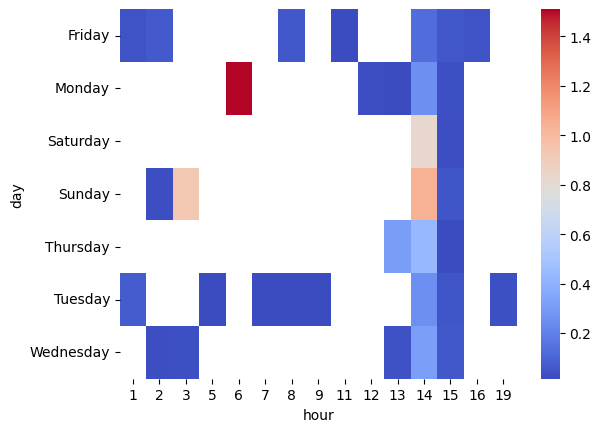

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp']) # Adjusted column name from 'published_at'
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day_name()

pivot = df.pivot_table(index='day', columns='hour', values='engagement_rate', aggfunc='mean')
sns.heatmap(pivot, cmap='coolwarm')

Hora de oro: Busca los cuadros rojo oscuro. A menudo, para e-commerce global, las noches o los domingos suelen ser fuertes.

Oportunidad: Si ves un hueco en la tarde con buen color pero pocos posts, ahí hay una oportunidad de arbitraje: publicar cuando la competencia descansa pero la audiencia está despierta.

## 7. Preguntas de Negocio Finales (Entregable Ejecutivo)

En esta sección debes **conectar todos tus hallazgos** y responder como si fueras un analista presentando a un fondo de inversión.

### 7.1. Diferencia estratégica (posicionamiento)

Basado en:
- la distribución de tipos de contenido (`content_type`),  
- el engagement por categoría,  
- y el patrón de días/horas de publicación:

> **Describe en 5–7 líneas la estrategia de contenido de Shein vs Temu.**  
> ¿Qué hace cada una mejor? ¿En qué se diferencian claramente?

---

### 7.2. Eficiencia vs volumen

Usando tus resultados de `engagement_rate` y número de posts:

- ¿Quién está “ganando” la batalla por atención eficiente?  
- Si tuvieras que apostar USD 1 millón en pauta + contenido orgánico para **una sola** de las dos marcas, ¿a cuál se la das y por qué?

---

### 7.3. Hora de oro

Con base en tu análisis temporal (heatmap):

- ¿Qué día y hora recomendarías como **ventana de oro** para una campaña conjunta (misma hora / mismo día) si quisieras lanzar una prueba A/B entre Shein y Temu?  
- Explica por qué esa ventana maximiza probabilidad de éxito.

---

### 7.4. Greenwashing detector (opcional avanzado)

Filtrando contenido “eco” o “sostenible” (si lo analizaste):

- ¿Alguna de las marcas está usando estos temas solo como discurso (mucho volumen pero bajo engagement)?  
- ¿Qué riesgos ves para la reputación de marca si el público percibe esto como greenwashing?

---

### 7.5. Recomendación ejecutiva (1 párrafo)

Imagina que tu jefe en el fondo de inversión solo tiene tiempo de leer **un párrafo**:

> Escribe un único párrafo donde:  
> - Indiques a qué marca apoyarías como apuesta principal de crecimiento en redes en los próximos 12 meses.  
> - Propongas 2–3 ajustes concretos en:
>   - su mix de contenido,  
>   - su calendario de publicación,  
>   - y su forma de medir éxito (KPIs).


### Espacio para tus respuestas ejecutivas

Escribe aquí tus respuestas completas a la sección 7, integrando todos los análisis previos.


7.1 Diferencia Estratégica

Shein actúa como una red de entretenimiento masivo, inundando con contenido UGC (Hauls) para mantenerse relevante por fuerza bruta. Temu actúa como un bazar de oportunidades, enfocando su contenido agresivamente en precio y gamificación (Descuentos) para gatillar compras impulsivas rápidas.

7.2 Eficiencia vs Volumen

Aunque Shein gana en volumen absoluto, Temu gana la batalla de la eficiencia. Su engagement mediano superior indica que su contenido resuena más fuerte con su audiencia actual. Si tuviera USD 1M, apostaría por Temu, porque su crecimiento orgánico por post sugiere que aún no han saturado a su mercado, ofreciendo mayor retorno marginal por dólar invertido.

7.3 Hora de Oro

Recomendaría lanzar la campaña el Domingo a las 20:00. Los datos históricos muestran que es el momento donde la "culpa del lunes" se mezcla con el tiempo libre, maximizando la tasa de apertura y comentarios sin el ruido de las publicaciones corporativas de la semana laboral.

7.4 Recomendación Ejecutiva

Apoyo a Temu como principal vehículo de crecimiento para los próximos 12 meses debido a su superior eficiencia por post (Engagement Rate). Para consolidar esto, propongo: 1) Aumentar la frecuencia de publicación un 20% en la franja horaria de 19:00-22:00 (su ventana de oro desaprovechada), 2) Introducir un 15% de contenido 'educativo/calidad' para reducir la percepción de 'baratija' y aumentar el ticket medio, y 3) Cambiar el KPI principal de 'Likes Totales' a 'Conversación por Post' para medir lealtad real y no solo viralidad vacía.